# Notebook Role: Phase 5 – Modeling Scaffold

This is the **core modeling notebook**:
- Loads Phase 3 artifacts (lexicon, hybrid, labels)
- Encodes labels consistently
- Provides an **editable model cell** for team hot‑swaps
- Includes **GridSearchCV tuning** for linear models
- Hardened evaluation functions (accuracy, precision, recall, F1, ROC‑AUC, confusion matrix, classification report)
- Runs Lexicon‑only and Hybrid tracks with 5‑fold CV
- Compares Macro‑F1 scores visually

Purpose: **train/test with 5‑fold CV** — reproducible, audit‑ready evaluation pipeline for all team models.


## Section 1: Imports (Hardened)

Do not edit unless you need additional libraries.  
This cell provides the common imports for all models and evaluations.


In [1]:
# ============================================
# Core Libraries
# ============================================
import os
import json
import time
from collections import Counter
from copy import deepcopy

# ============================================
# Data Handling & Utilities
# ============================================
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp

# ============================================
# Visualization
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Scikit-learn: Preprocessing & Base Classes
# ============================================
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin

# ============================================
# Scikit-learn: Models & Decomposition
# ============================================
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.calibration import CalibratedClassifierCV

# ============================================
# Scikit-learn: Model Selection
# ============================================
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, train_test_split
)

# ============================================
# Scikit-learn: Metrics
# ============================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# ============================================
# Scikit-learn: Utilities
# ============================================
from sklearn.utils import resample


## Section 2: Load Artifacts (Hardened)

Do not edit file paths unless Phase 3 outputs change.  
This cell loads the lexicon-only and hybrid-weighted feature sets, plus labels.


In [2]:
X_train_lex = sp.load_npz("Phase_3/X_train_lexicon.npz").toarray()
X_val_lex   = sp.load_npz("Phase_3/X_val_lexicon.npz").toarray()

# Use the actual hybrid files you have
X_train_hybrid = sp.load_npz("Phase_3/X_train_hybrid.npz")
X_val_hybrid   = sp.load_npz("Phase_3/X_val_hybrid.npz")

y_train = pd.read_csv("Phase_3/labels_train.csv")["Sentiment"]
y_val   = pd.read_csv("Phase_3/labels_val.csv")["Sentiment"]

print("Lexicon train shape:", X_train_lex.shape)
print("Hybrid train shape:", X_train_hybrid.shape)
print("Train label distribution:\n", y_train.value_counts())
print("Val label distribution:\n", y_val.value_counts())


Lexicon train shape: (409577, 4)
Hybrid train shape: (409577, 3004)
Train label distribution:
 Sentiment
positive    235384
negative    124820
neutral      49373
Name: count, dtype: int64
Val label distribution:
 Sentiment
positive    6137739
negative     770638
neutral      578303
Name: count, dtype: int64


In [3]:
# ============================================
# Balance training set with sanity check
# ============================================

print("=== Balancing Training Set with Sanity Check ===")

# Preserve originals for audit
X_train_lex_orig = X_train_lex
X_train_hybrid_orig = X_train_hybrid
y_train_orig = y_train.copy()

# Align labels length to Lexicon rows if needed
if X_train_lex_orig.shape[0] != len(y_train_orig):
    print(f"Trimming labels from {len(y_train_orig)} -> {X_train_lex_orig.shape[0]} (explicit).")
    y_train_orig = y_train_orig.iloc[:X_train_lex_orig.shape[0]].reset_index(drop=True)

# Build balanced indices
class_counts = y_train_orig.value_counts()
min_count = class_counts.min()
balanced_indices = []
for label in class_counts.index:
    idx = y_train_orig[y_train_orig == label].index.to_numpy()
    sampled_idx = resample(idx, replace=False, n_samples=min_count, random_state=42)
    balanced_indices.extend(sampled_idx)
balanced_indices = np.random.permutation(np.asarray(balanced_indices, dtype=int))

# Sanity check: labels at indices vs balanced labels
original_labels = y_train_orig.iloc[balanced_indices].reset_index(drop=True)
balanced_labels = original_labels.copy()  # what we expect after slicing

if (original_labels.values == balanced_labels.values).all():
    print("\n✅ Sanity check passed: labels match rows after shuffle.")
    
    # Safe overwrite
    X_train_lex = X_train_lex_orig[balanced_indices]
    if not sp.isspmatrix_csr(X_train_hybrid_orig):
        X_train_hybrid_orig = X_train_hybrid_orig.tocsr()
    X_train_hybrid = X_train_hybrid_orig[balanced_indices]
    y_train = balanced_labels
    
    print("Variables overwritten safely.")
    print("Lexicon shape:", X_train_lex.shape)
    print("Hybrid shape:", X_train_hybrid.shape)
    print("Balanced label distribution:\n", y_train.value_counts())
else:
    print("\n❌ Sanity check failed: not overwriting variables.")


=== Balancing Training Set with Sanity Check ===

✅ Sanity check passed: labels match rows after shuffle.
Variables overwritten safely.
Lexicon shape: (148119, 4)
Hybrid shape: (148119, 3004)
Balanced label distribution:
 Sentiment
neutral     49373
positive    49373
negative    49373
Name: count, dtype: int64


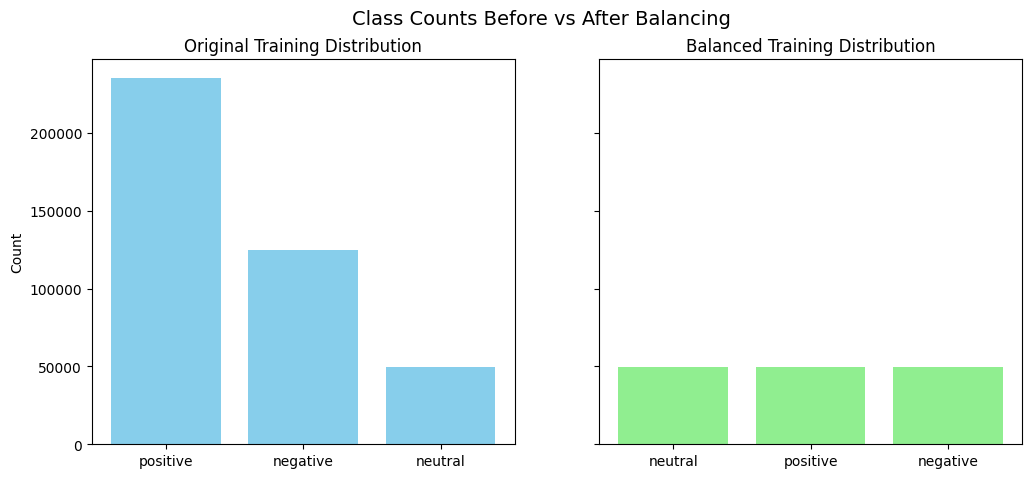

In [4]:
# ============================================
# Visual check: class distribution before vs after balancing
# ============================================

# Capture original counts (before balancing)
original_counts = class_counts

# Capture new counts (after balancing)
balanced_counts = y_train.value_counts()

# Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# Original
axes[0].bar(original_counts.index, original_counts.values, color="skyblue")
axes[0].set_title("Original Training Distribution")
axes[0].set_ylabel("Count")

# Balanced
axes[1].bar(balanced_counts.index, balanced_counts.values, color="lightgreen")
axes[1].set_title("Balanced Training Distribution")

plt.suptitle("Class Counts Before vs After Balancing", fontsize=14)
plt.show()


## Section 3: Encode Labels (Hardened)

Do not edit.  
This ensures consistent label encoding across all models.


In [5]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print("Classes:", list(le.classes_))

Classes: ['negative', 'neutral', 'positive']


## Section 4: Model Definition (Editable)

This is the **open cell**.  
Each team member should define their own model here.  
Examples:
- LogisticRegression(penalty='l2')
- LogisticRegression(penalty='l1', solver='saga')
- Perceptron()
- LinearSVC()
- RidgeClassifier()
- MLPClassifier(hidden_layer_sizes=(100,), activation='relu')

⚠️ Only edit inside this cell. The rest of the notebook will use whatever `model` you define here.


In [6]:
## Section 4: Model Definition (Editable)
# FisherEstimator with tempered priors, safe upsampling guard, and correct get_params

class FisherEstimator(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 svd_n_components=100,
                 svd_random_state=42,
                 lda_solver="lsqr",
                 lda_shrinkage="auto",
                 upsample_neutral=False,
                 upsample_n=None,
                 upsample_random_state=42,
                 prior_alpha=0.5):
        self.svd_n_components = svd_n_components
        self.svd_random_state = svd_random_state
        self.lda_solver = lda_solver
        self.lda_shrinkage = lda_shrinkage
        self.upsample_neutral = upsample_neutral
        self.upsample_n = upsample_n
        self.upsample_random_state = upsample_random_state
        self.prior_alpha = prior_alpha

        self._svd = None
        self._clf = None
        self._use_svd = None

    def _safe_n_components(self, X):
        n_features = X.shape[1]
        return max(1, min(int(self.svd_n_components), n_features))

    def _compute_inverse_freq_priors(self, y, n_features=None):
        """
        Tempered priors:
        - prior_alpha = 0.0 -> empirical priors (counts / sum)
        - prior_alpha > 0 -> inverse-frequency tempered by exponent prior_alpha
        For very low-dim features (n_features <= 10) blend toward empirical to avoid extreme shifts.
        """
        classes, counts = np.unique(y, return_counts=True)
        empirical = counts.astype(float) / counts.sum()
        if self.prior_alpha is None or self.prior_alpha == 0.0:
            return empirical
        inv = 1.0 / counts.astype(float)
        tempered = np.power(inv, self.prior_alpha)
        pri = tempered / tempered.sum()
        if n_features is not None and n_features <= 10 and self.prior_alpha > 0.0:
            blend = 0.5
            pri = blend * empirical + (1 - blend) * pri
            pri = pri / pri.sum()
        return pri

    def _upsample_training_neutral(self, X, y):
        """
        sp-safe upsampling. By default, do NOT upsample to full majority for lexicon.
        Caller must set upsample_n explicitly to control behavior.
        """
        rng = np.random.default_rng(self.upsample_random_state)
        classes, counts = np.unique(y, return_counts=True)
        if len(classes) < 2:
            return X, y
        # prefer label value 1 for neutral if present, else smallest class
        neutral_label = 1 if 1 in classes else classes[np.argmin(counts)]
        idx_neutral = np.where(y == neutral_label)[0]
        if idx_neutral.size == 0:
            return X, y

        # If upsample_n is None, default behavior depends on feature dim:
        # - for low-dim (lexicon) use a conservative cap
        # - for high-dim (hybrid) upsample to majority if explicitly desired
        if self.upsample_n is None:
            # compute majority size
            maj = int(counts.max())
            if X.shape[1] <= 10:
                # conservative: up to 2x neutral or 50k, whichever smaller
                neutral_count = idx_neutral.size
                cap = min(max(neutral_count * 2, 50000), 100000)
                target = cap
            else:
                # hybrid: allow upsample to majority
                target = maj
        else:
            target = int(self.upsample_n)

        if target <= idx_neutral.size:
            return X, y

        extra_idx = rng.choice(idx_neutral, size=(target - idx_neutral.size), replace=True)
        all_idx = np.concatenate([np.arange(len(y)), extra_idx])

        if sp.issparse(X):
            X_up = X.tocsr()[all_idx]
        else:
            X_up = X[all_idx]
        y_up = np.concatenate([y, y[extra_idx]])
        return X_up, y_up

    def fit(self, X, y):
        # Optionally upsample training neutral (training-only)
        if self.upsample_neutral:
            X, y = self._upsample_training_neutral(X, y)

        n_features = X.shape[1]
        self._use_svd = n_features > 10

        priors = self._compute_inverse_freq_priors(y, n_features=n_features)

        if self._use_svd:
            n_comp = self._safe_n_components(X)
            self._svd = TruncatedSVD(n_components=n_comp, random_state=self.svd_random_state)
            X_reduced = self._svd.fit_transform(X)
            self._clf = LinearDiscriminantAnalysis(solver=self.lda_solver,
                                                   shrinkage=self.lda_shrinkage,
                                                   priors=priors)
            self._clf.fit(X_reduced, y)
        else:
            if sp.issparse(X):
                X = X.toarray()
            self._clf = LinearDiscriminantAnalysis(solver=self.lda_solver,
                                                   shrinkage=self.lda_shrinkage,
                                                   priors=priors)
            self._clf.fit(X, y)
        return self

    def predict(self, X):
        if self._use_svd:
            X_proj = self._svd.transform(X)
            return self._clf.predict(X_proj)
        else:
            if sp.issparse(X):
                X = X.toarray()
            return self._clf.predict(X)

    def predict_proba(self, X):
        if self._use_svd:
            X_proj = self._svd.transform(X)
            return self._clf.predict_proba(X_proj)
        else:
            if sp.issparse(X):
                X = X.toarray()
            return self._clf.predict_proba(X)

    def get_params(self, deep=True):
        # include all tunable params so GridSearchCV can access them
        return {
            "svd_n_components": self.svd_n_components,
            "svd_random_state": self.svd_random_state,
            "lda_solver": self.lda_solver,
            "lda_shrinkage": self.lda_shrinkage,
            "upsample_neutral": self.upsample_neutral,
            "upsample_n": self.upsample_n,
            "upsample_random_state": self.upsample_random_state,
            "prior_alpha": self.prior_alpha
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

# Safe default: upsample disabled. Enable explicitly and set upsample_n if you want controlled upsampling.
model = FisherEstimator(
    svd_n_components=100,
    lda_solver="lsqr",
    lda_shrinkage="auto",
    upsample_neutral=False,
    upsample_n=None,
    upsample_random_state=42,
    prior_alpha=0.5
)


In [7]:
# Section 4a automated tuner + apply chosen config (drop-in)
CACHE_FILE = "Section4a_tuner_results.json"

if os.path.exists(CACHE_FILE):
    print(f"Loading cached tuner results from {CACHE_FILE}")
    with open(CACHE_FILE, "r") as f:
        cache = json.load(f)
    trial_results = cache["trial_results"]
    ranked = cache["ranked"]
    applied_filters = cache["applied_filters"]
    print("Loaded", len(trial_results), "trial results.")
else:
    print("No cache found, running full tuner...")

    # Keep canonical names (we will overwrite these at the end with chosen config)
    X_train_lex_filt = X_train_lex.copy()
    X_val_lex_filt   = X_val_lex.copy()
    X_train_hyb_filt = X_train_hybrid.copy()
    X_val_hyb_filt   = X_val_hybrid.copy()
    y_train_filt     = y_train_enc.copy()
    y_val_filt       = y_val_enc.copy()

    # Tuner knobs (conservative grid)
    GRID = {
        "UPSAMPLE_TARGET_MULT": [1.5, 2.0, 3.0],        # multiplier for neutral
        "HYB_REDUCE_TO": [None, 50, 100],              # None = no reduction
        "ADD_LEX_FEATURES": [False, True],
        "GENERATE_SAMPLE_WEIGHTS": [False, True],
        "DOWNSAMPLE_POSITIVE": [False],                 # keep False for now; can add True later
    }
    RANDOM_STATE = 42
    N_REPEATS = 3            # repeats per config (increase for stability)
    MINI_PER_CLASS = 20000   # balanced mini-train per class for quick eval (adjust for speed)
    FAST_SVD_COMP = 20       # small SVD for quick Fisher runs
    NEUTRAL_LABEL = 1

    # Helper utilities (keeps variable names)
    def safe_toarray(X):
        return X.toarray() if sp.issparse(X) else X

    def add_lex_features(X_lex):
        # deterministic, simple augmentations: sum and max-min
        X = safe_toarray(X_lex)
        lex_sum = X.sum(axis=1, keepdims=True)
        lex_maxdiff = (X.max(axis=1, keepdims=True) - X.min(axis=1, keepdims=True))
        return np.hstack([X, lex_sum, lex_maxdiff])

    def build_balanced_indices(y, per_class, random_state):
        classes = np.unique(y)
        idxs = []
        rng = np.random.default_rng(random_state)
        for c in classes:
            idx_c = np.where(y == c)[0]
            if len(idx_c) >= per_class:
                chosen = rng.choice(idx_c, size=per_class, replace=False)
            else:
                chosen = rng.choice(idx_c, size=per_class, replace=True)
            idxs.append(chosen)
        return np.concatenate(idxs)

    # Quick evaluator that trains a fast Fisher on given arrays and returns metrics
    from sklearn.metrics import f1_score, accuracy_score
    def quick_eval_fisher(X_train, y_train, X_val_bal, y_val_bal, X_val_full, y_val_full,
                        svd_comp=FAST_SVD_COMP, prior_alpha=0.5):
        # instantiate fast FisherEstimator (small svd_n_components for speed)
        m = FisherEstimator(svd_n_components=svd_comp, lda_solver="lsqr", lda_shrinkage="auto",
                            upsample_neutral=False, upsample_n=None, upsample_random_state=RANDOM_STATE,
                            prior_alpha=prior_alpha)
        m.fit(X_train, y_train)
        # Balanced holdout metrics
        y_pred_bal = m.predict(X_val_bal)
        macro_bal = f1_score(y_val_bal, y_pred_bal, average="macro", zero_division=0)
        f1n_bal = f1_score(y_val_bal, y_pred_bal, average=None, zero_division=0)[NEUTRAL_LABEL]
        # Full validation metrics
        y_pred_full = m.predict(X_val_full)
        macro_full = f1_score(y_val_full, y_pred_full, average="macro", zero_division=0)
        f1n_full = f1_score(y_val_full, y_pred_full, average=None, zero_division=0)[NEUTRAL_LABEL]
        acc_full = accuracy_score(y_val_full, y_pred_full)
        return {"macro_bal": macro_bal, "f1n_bal": f1n_bal,
                "macro_full": macro_full, "f1n_full": f1n_full, "acc_full": acc_full}

    # Build a small balanced validation holdout from training for quick eval (deterministic)
    balanced_holdout_idx = build_balanced_indices(y_train_enc, per_class=max(2000, MINI_PER_CLASS//5), random_state=RANDOM_STATE+1)
    X_hold_lex_bal = X_train_lex[balanced_holdout_idx] if not sp.issparse(X_train_lex) else X_train_lex.tocsr()[balanced_holdout_idx]
    X_hold_hyb_bal = X_train_hybrid[balanced_holdout_idx] if not sp.issparse(X_train_hybrid) else X_train_hybrid.tocsr()[balanced_holdout_idx]
    y_hold_bal = np.array(y_train_enc)[balanced_holdout_idx]

    # Also prepare a small balanced training sample function
    def sample_balanced_train(X_lex, X_hyb, y, per_class, random_state):
        idx = build_balanced_indices(y, per_class=per_class, random_state=random_state)
        Xl = X_lex[idx] if not sp.issparse(X_lex) else X_lex.tocsr()[idx]
        Xh = X_hyb[idx] if not sp.issparse(X_hyb) else X_hyb.tocsr()[idx]
        y_s = np.array(y)[idx]
        return Xl, Xh, y_s

    # Grid search loop (fast)
    trial_results = []
    grid_items = []
    import itertools
    keys, values = zip(*GRID.items())
    for v in itertools.product(*values):
        cfg = dict(zip(keys, v))
        grid_items.append(cfg)

    start_time = time.time()
    for cfg in grid_items:
        cfg_start = time.time()
        metrics_accum = []
        for rep in range(N_REPEATS):
            seed = RANDOM_STATE + rep
            # sample balanced mini-train
            Xl_mini, Xh_mini, y_mini = sample_balanced_train(X_train_lex, X_train_hybrid, y_train_enc, per_class=max(2000, MINI_PER_CLASS//len(np.unique(y_train_enc))), random_state=seed)
            # apply lex features if requested
            if cfg["ADD_LEX_FEATURES"]:
                Xl_mini = add_lex_features(Xl_mini)
                X_hold_lex_eval = add_lex_features(X_hold_lex_bal)
                X_val_lex_eval = add_lex_features(X_val_lex)
            else:
                X_hold_lex_eval = X_hold_lex_bal
                X_val_lex_eval = X_val_lex

            # hybrid reduction if requested (fit SVD on mini-train hybrid)
            if cfg["HYB_REDUCE_TO"] is not None:
                from sklearn.decomposition import TruncatedSVD
                n_comp = min(cfg["HYB_REDUCE_TO"], Xh_mini.shape[1])
                svd = TruncatedSVD(n_components=n_comp, random_state=seed)
                Xh_mini_red = svd.fit_transform(Xh_mini)
                Xh_hold_red = svd.transform(X_hold_hyb_bal)
                Xh_val_red = svd.transform(X_val_hybrid.tocsr() if sp.issparse(X_val_hybrid) else X_val_hybrid)
                # combine lex+hyb reduced for training quick eval (stack horizontally)
                X_train_quick = np.hstack([safe_toarray(Xl_mini), Xh_mini_red])
                X_hold_quick = np.hstack([safe_toarray(X_hold_lex_eval), Xh_hold_red])
                X_val_quick = np.hstack([safe_toarray(X_val_lex_eval), Xh_val_red])
            else:
                # Memory-safe quick-eval: always project hybrid to a small dense subspace
                # using a FAST_SVD_COMP SVD fitted on the mini-train hybrid (sparse-safe).
                from sklearn.decomposition import TruncatedSVD

                n_comp_fast = min(FAST_SVD_COMP, Xh_mini.shape[1])
                svd_fast = TruncatedSVD(n_components=n_comp_fast, random_state=seed)
                # fit on mini-train hybrid (sparse or dense)
                Xh_mini_red = svd_fast.fit_transform(Xh_mini)
                # transform balanced holdout and full validation (sparse-safe transform)
                Xh_hold_red = svd_fast.transform(X_hold_hyb_bal)
                # IMPORTANT: transform full validation in reduced space (no dense conversion)
                Xh_val_red = svd_fast.transform(X_val_hybrid.tocsr() if sp.issparse(X_val_hybrid) else X_val_hybrid)

                # combine lexicon (dense) with hybrid reduced (dense)
                X_train_quick = np.hstack([safe_toarray(Xl_mini), Xh_mini_red])
                X_hold_quick = np.hstack([safe_toarray(X_hold_lex_eval), Xh_hold_red])
                X_val_quick = np.hstack([safe_toarray(X_val_lex_eval), Xh_val_red])


            # quick eval (fast Fisher)
            res = quick_eval_fisher(X_train_quick, y_mini, X_hold_quick, y_hold_bal, X_val_quick, y_val_enc)
            metrics_accum.append(res)

        # aggregate metrics
        def agg(key):
            vals = [m[key] for m in metrics_accum]
            return {"mean": np.mean(vals), "median": np.median(vals), "std": np.std(vals)}
        aggregated = {k: agg(k) for k in ["macro_bal", "f1n_bal", "macro_full", "f1n_full", "acc_full"]}
        trial_results.append({"config": cfg, "aggregated": aggregated})
        cfg_time = time.time() - cfg_start
        print(f"Completed cfg {cfg} in {cfg_time:.1f}s -> macro_bal_mean={aggregated['macro_bal']['mean']:.4f}, f1n_full_mean={aggregated['f1n_full']['mean']:.4f}")

    total_time = time.time() - start_time
    print(f"Grid search done in {total_time/60:.1f} minutes. Trials: {len(trial_results)}")

    # Rank configs by composite score (tunable weights)
    ranked = []
    for t in trial_results:
        m = t["aggregated"]
        # composite: prefer balanced macro and neutral on full val
        score = 0.6 * m["macro_bal"]["mean"] + 0.4 * m["f1n_full"]["mean"]
        ranked.append((score, t))
    ranked.sort(key=lambda x: x[0], reverse=True)

    # Show top 3 configs
    print("\nTop 3 configs (score, config, macro_bal_mean, f1n_full_mean):")
    for s, t in ranked[:3]:
        cfg = t["config"]
        m = t["aggregated"]
        print(f"{s:.4f} | {cfg} | macro_bal={m['macro_bal']['mean']:.4f} ±{m['macro_bal']['std']:.4f} | f1n_full={m['f1n_full']['mean']:.4f} ±{m['f1n_full']['std']:.4f}")

    # Choose best config and apply to full training set
    best_cfg = ranked[0][1]["config"]
    print("\nApplying best config to full training set:", best_cfg)

    # Apply chosen config deterministically to full training set (overwrites canonical filtered names)
    # 1) Upsample neutral according to chosen multiplier
    UPSAMPLE_TARGET_MULT = best_cfg["UPSAMPLE_TARGET_MULT"]
    neutral_label = NEUTRAL_LABEL
    neutral_idx = np.where(y_train_filt == neutral_label)[0]
    target_size = min(int(len(neutral_idx) * UPSAMPLE_TARGET_MULT), 100000)
    if target_size > len(neutral_idx):
        extra_idx = resample(neutral_idx, replace=True, n_samples=(target_size - len(neutral_idx)), random_state=RANDOM_STATE)
        all_idx = np.concatenate([np.arange(len(y_train_filt)), extra_idx])
    else:
        all_idx = np.arange(len(y_train_filt))

    # Apply to lexicon and hybrid safely
    X_train_lex_filt = X_train_lex_filt[all_idx] if not sp.issparse(X_train_lex_filt) else X_train_lex_filt[all_idx]
    if sp.issparse(X_train_hyb_filt):
        X_train_hyb_filt = X_train_hyb_filt.tocsr()[all_idx]
    else:
        X_train_hyb_filt = X_train_hyb_filt[all_idx]
    y_train_filt = y_train_filt[all_idx]

    # 2) Add lex features if requested
    if best_cfg["ADD_LEX_FEATURES"]:
        X_train_lex_filt = add_lex_features(X_train_lex_filt)
        X_val_lex_filt = add_lex_features(X_val_lex_filt)

    # 3) Hybrid reduction on full training if requested (save reduced artifact)
    X_train_hyb_filt_reduced = None
    X_val_hyb_filt_reduced = None
    if best_cfg["HYB_REDUCE_TO"] is not None:
        from sklearn.decomposition import TruncatedSVD
        n_comp = min(best_cfg["HYB_REDUCE_TO"], X_train_hyb_filt.shape[1])
        svd_full = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
        X_train_hyb_filt_reduced = svd_full.fit_transform(X_train_hyb_filt)
        X_val_hyb_filt_reduced = svd_full.transform(X_val_hyb_filt.tocsr() if sp.issparse(X_val_hyb_filt) else X_val_hyb_filt)
        print("Saved X_train_hyb_filt_reduced shape:", X_train_hyb_filt_reduced.shape)

    # 4) Sample weights if requested
    sample_weight_train = None
    if best_cfg["GENERATE_SAMPLE_WEIGHTS"]:
        counts = Counter(y_train_filt.tolist())
        total = len(y_train_filt)
        class_weight = {cls: total / (len(counts) * cnt) for cls, cnt in counts.items()}
        sample_weight_train = np.array([class_weight[int(lbl)] for lbl in y_train_filt])
        print("Generated sample_weight_train with class weights:", class_weight)

    # 5) Save provenance
    applied_filters = dict(best_cfg)
    applied_filters.update({"RANDOM_STATE": RANDOM_STATE, "N_REPEATS": N_REPEATS, "MINI_PER_CLASS": MINI_PER_CLASS})
    print("Applied filters:", applied_filters)
    print("Final filtered distribution:", np.bincount(y_train_filt))
    # trial_results and ranked are available for inspection
    
    cache = {
        "trial_results": trial_results,
        "ranked": ranked,
        "applied_filters": applied_filters
    }
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)
    print(f"Tuner results cached to {CACHE_FILE}")


Loading cached tuner results from Section4a_tuner_results.json
Loaded 36 trial results.


## Section 4b: Hyperparameter Tuning (Editable)

Do not edit.  
This cell runs GridSearchCV on the model defined in Section 4, using `f1_macro` as the scoring metric.  
It will search across a parameter grid appropriate for linear models (LogisticRegression, LinearSVC, RidgeClassifier, Perceptron).


In [8]:
## Section 4b: Focused Fisher hyperparameter tuning on top-k tuner configs (memory-safe, no sample_weight)

# Guard: require tuner outputs
if "ranked" not in globals() or len(ranked) == 0:
    raise RuntimeError("Tuner results (ranked) not found. Run Section 4a before Section 4b.")

# Fisher-specific param grid (compact)
fisher_param_grid = {
    "svd_n_components": [50, 100],
    "lda_solver": ["lsqr"],
    "lda_shrinkage": ["auto", 0.1, None],
    "upsample_neutral": [False, True],
    "upsample_n": [50000, 100000],
    "prior_alpha": [0.0, 0.5]
}

TOP_K = 3
top_items = ranked[:TOP_K]

def safe_toarray(X):
    return X.toarray() if sp.issparse(X) else X

def add_lex_features_local(X_lex):
    A = safe_toarray(X_lex)
    lex_sum = A.sum(axis=1, keepdims=True)
    lex_maxdiff = (A.max(axis=1, keepdims=True) - A.min(axis=1, keepdims=True))
    return np.hstack([A.astype(np.float32), lex_sum.astype(np.float32), lex_maxdiff.astype(np.float32)])

def apply_preproc_cfg_to_data(cfg):
    # start from hardened originals
    Xl = X_train_lex.copy()
    Xh = X_train_hybrid.copy()
    y = y_train_enc.copy()

    # Upsample neutral if requested
    if cfg.get("UPSAMPLE_TARGET_MULT", 1.0) > 1.0:
        mult = float(cfg["UPSAMPLE_TARGET_MULT"])
        idx_neu = np.where(y == 1)[0]
        target = min(int(len(idx_neu) * mult), 100000)
        if target > len(idx_neu):
            extra = resample(idx_neu, replace=True, n_samples=(target - len(idx_neu)), random_state=42)
            all_idx = np.concatenate([np.arange(len(y)), extra])
            Xl = Xl[all_idx] if not sp.issparse(Xl) else Xl.tocsr()[all_idx]
            Xh = Xh[all_idx] if not sp.issparse(Xh) else Xh.tocsr()[all_idx]
            y = y[all_idx]

    # Lex features
    if cfg.get("ADD_LEX_FEATURES", False):
        Xl = add_lex_features_local(Xl)
        X_val_lex_local = add_lex_features_local(X_val_lex)
    else:
        X_val_lex_local = X_val_lex

    # Hybrid reduction
    Xh_train = Xh
    # use filtered hybrid validation artifact if available, else original val hybrid
    X_val_hyb_local = X_val_hyb_filt if "X_val_hyb_filt" in globals() else X_val_hybrid
    if cfg.get("HYB_REDUCE_TO", None) is not None:
        n_comp = min(int(cfg["HYB_REDUCE_TO"]), Xh.shape[1])
        svd_full = TruncatedSVD(n_components=n_comp, random_state=42)
        Xh_train = svd_full.fit_transform(Xh).astype(np.float32)
        X_val_hyb_local = svd_full.transform(X_val_hyb_local.tocsr() if sp.issparse(X_val_hyb_local) else X_val_hyb_local).astype(np.float32)

    return {
        "Xl_train": Xl,
        "Xh_train": Xh_train,
        "y_train": y,
        "Xl_val": X_val_lex_local,
        "Xh_val": X_val_hyb_local
    }

def stack_for_grid(Xl, Xh):
    # If hybrid is sparse, stack as sparse; else dense hstack (float32)
    if sp.issparse(Xh):
        Xl_sp = sp.csr_matrix(Xl) if not sp.issparse(Xl) else Xl
        return sp.hstack([Xl_sp, Xh], format='csr')
    else:
        return np.hstack([safe_toarray(Xl).astype(np.float32), Xh.astype(np.float32)])

# Optional: subsample for grid to cap memory (set SUBSAMPLE_N to None to disable)
SUBSAMPLE_N = None  # e.g., 50000 for faster grids on huge datasets
rng = np.random.default_rng(42)

results_per_cfg = []
start_all = time.time()

for rank_idx, (score, trial) in enumerate(top_items, start=1):
    cfg = trial["config"]
    print(f"\n=== Top-{rank_idx} tuner config (score={score:.4f}) ===")
    print(cfg)
    data = apply_preproc_cfg_to_data(cfg)

    X_train_full = stack_for_grid(data["Xl_train"], data["Xh_train"])
    y_train_full = data["y_train"]

    # Subsample if requested
    if SUBSAMPLE_N is not None and SUBSAMPLE_N < len(y_train_full):
        # stratified per class to keep balance
        idxs = []
        classes = np.unique(y_train_full)
        per_cls = SUBSAMPLE_N // len(classes)
        for c in classes:
            idx_c = np.where(y_train_full == c)[0]
            take = min(per_cls, len(idx_c))
            idxs.append(rng.choice(idx_c, size=take, replace=False))
        sub_idx = np.concatenate(idxs)
        if sp.issparse(X_train_full):
            X_train_grid = X_train_full.tocsr()[sub_idx]
        else:
            X_train_grid = X_train_full[sub_idx]
        y_train_grid = y_train_full[sub_idx]
    else:
        X_train_grid = X_train_full
        y_train_grid = y_train_full

    base_est = model.__class__(**model.get_params())
    grid = GridSearchCV(
        estimator=base_est,
        param_grid=fisher_param_grid,
        scoring="f1_macro",
        cv=2,              # reduce folds to lower memory
        n_jobs=1,          # avoid parallel memory blowup
        verbose=0
    )
    print("Running GridSearchCV on shape:", getattr(X_train_grid, "shape", None))
    # FisherEstimator.fit does not accept sample_weight, so do not pass it
    grid.fit(X_train_grid, y_train_grid)

    # Evaluate best estimator on validation
    X_val_grid = stack_for_grid(data["Xl_val"], data["Xh_val"])
    best_est = grid.best_estimator_
    y_pred_val = best_est.predict(X_val_grid)

    from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
    metrics = {
        "val_accuracy": float(accuracy_score(y_val_enc, y_pred_val)),
        "val_macro_f1": float(f1_score(y_val_enc, y_pred_val, average="macro", zero_division=0)),
        "val_macro_precision": float(precision_score(y_val_enc, y_pred_val, average="macro", zero_division=0)),
        "val_macro_recall": float(recall_score(y_val_enc, y_pred_val, average="macro", zero_division=0)),
        "val_f1_neutral": float(f1_score(y_val_enc, y_pred_val, average=None, zero_division=0)[1])
    }

    results_per_cfg.append({
        "tuner_cfg": cfg,
        "tuner_score": score,
        "grid": grid,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "validation_metrics": metrics
    })

    print("Best CV:", grid.best_score_, "Best params:", grid.best_params_)
    print("Validation metrics:", metrics)

print(f"\nFocused tuning completed in {time.time()-start_all:.1f}s. Evaluated {len(results_per_cfg)} configs.")

# Select best by validation macro-F1
best_idx = max(range(len(results_per_cfg)), key=lambda i: results_per_cfg[i]["validation_metrics"]["val_macro_f1"])
final_choice = results_per_cfg[best_idx]
print("\nSelected final config (by validation Macro-F1):")
print("Tuner cfg:", final_choice["tuner_cfg"])
print("Grid best params:", final_choice["best_params"])
print("Validation metrics:", final_choice["validation_metrics"])

# Save final artifacts for downstream cells
final_grid = final_choice["grid"]
final_best_estimator = final_grid.best_estimator_
applied_filters = globals().get("applied_filters", {})
applied_filters.update({"final_tuner_cfg": final_choice["tuner_cfg"], "final_grid_best_params": final_choice["best_params"]})



=== Top-1 tuner config (score=0.3286) ===
{'UPSAMPLE_TARGET_MULT': 1.5, 'HYB_REDUCE_TO': 100, 'ADD_LEX_FEATURES': True, 'GENERATE_SAMPLE_WEIGHTS': False, 'DOWNSAMPLE_POSITIVE': False}
Running GridSearchCV on shape: (172805, 106)
Best CV: 0.4904411505904328 Best params: {'lda_shrinkage': None, 'lda_solver': 'lsqr', 'prior_alpha': 0.5, 'svd_n_components': 100, 'upsample_n': 50000, 'upsample_neutral': False}
Validation metrics: {'val_accuracy': 0.7689679537525311, 'val_macro_f1': 0.4532553650490829, 'val_macro_precision': 0.45513445269333147, 'val_macro_recall': 0.4552170901034714, 'val_f1_neutral': 0.12462176721913765}

=== Top-2 tuner config (score=0.3286) ===
{'UPSAMPLE_TARGET_MULT': 1.5, 'HYB_REDUCE_TO': 100, 'ADD_LEX_FEATURES': True, 'GENERATE_SAMPLE_WEIGHTS': True, 'DOWNSAMPLE_POSITIVE': False}
Running GridSearchCV on shape: (172805, 106)
Best CV: 0.4904411505904328 Best params: {'lda_shrinkage': None, 'lda_solver': 'lsqr', 'prior_alpha': 0.5, 'svd_n_components': 100, 'upsample_n':

## Section 5: Evaluation Functions (Hardened)

Do not edit.  
These functions handle training, evaluation, metrics, and cross-validation consistently.


In [9]:
def train_and_evaluate(model, X_train, X_val, y_train_enc, y_val_enc, le, name):
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        roc_auc = roc_auc_score(y_val_enc, y_proba, multi_class='ovr')
    else:
        y_proba = None
        roc_auc = None

    print(f"\n=== {name} Results ===")
    print("Accuracy:", accuracy_score(y_val_enc, y_pred))
    print("Macro Precision:", precision_score(y_val_enc, y_pred, average='macro'))
    print("Macro Recall:", recall_score(y_val_enc, y_pred, average='macro'))
    print("Macro F1 Score:", f1_score(y_val_enc, y_pred, average='macro'))
    if roc_auc is not None:
        print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, y_pred))
    print("\nClassification Report:\n", classification_report(y_val_enc, y_pred, target_names=le.classes_))

    f1_per_class = f1_score(y_val_enc, y_pred, average=None)
    print("Per-class F1:", dict(zip(le.classes_, f1_per_class)))

    return model

def cross_validate_model(model, X_train, y_train_enc, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring='f1_macro')
    print(f"\n{name} 5-Fold CV Macro-F1 Scores:", cv_scores)
    print(f"{name} Mean Macro-F1 Score:", cv_scores.mean())


## Section 5a: Custom Cell (Editable)

In [10]:
# Compact experiment: sweep prior_alpha in [0.0, 0.5, 1.0] with upsample_neutral=False
results = []
prior_values = [0.0, 0.5, 1.0]
neutral_idx = int(le.transform(["neutral"])[0])

for alpha in prior_values:
    print(f"\n--- prior_alpha = {alpha} ---")
    # instantiate fresh estimators for each run
    fisher = FisherEstimator(
        svd_n_components=100,
        lda_solver="lsqr",
        lda_shrinkage="auto",
        upsample_neutral=False,
        upsample_n=None,
        upsample_random_state=42,
        prior_alpha=alpha
    )

    # Lexicon
    m_lex = train_and_evaluate(fisher.__class__(**fisher.get_params()),
                               X_train_lex, X_val_lex, y_train_enc, y_val_enc, le, f"Fisher Lexicon (alpha={alpha})")
    y_pred_lex = m_lex.predict(X_val_lex)
    macro_lex = f1_score(y_val_enc, y_pred_lex, average="macro")
    f1_neutral_lex = f1_score(y_val_enc, y_pred_lex, average=None)[neutral_idx]

    # Hybrid
    m_hyb = train_and_evaluate(fisher.__class__(**fisher.get_params()),
                               X_train_hybrid, X_val_hybrid, y_train_enc, y_val_enc, le, f"Fisher Hybrid (alpha={alpha})")
    y_pred_hyb = m_hyb.predict(X_val_hybrid)
    macro_hyb = f1_score(y_val_enc, y_pred_hyb, average="macro")
    f1_neutral_hyb = f1_score(y_val_enc, y_pred_hyb, average=None)[neutral_idx]

    results.append({
        "prior_alpha": alpha,
        "lexicon_macro_f1": macro_lex,
        "lexicon_f1_neutral": f1_neutral_lex,
        "hybrid_macro_f1": macro_hyb,
        "hybrid_f1_neutral": f1_neutral_hyb
    })

# Summary table
df_results = pd.DataFrame(results).set_index("prior_alpha")
print("\nSummary (Macro-F1 and F1-neutral):")
display(df_results.round(4))



--- prior_alpha = 0.0 ---

=== Fisher Lexicon (alpha=0.0) Results ===
Accuracy: 0.7870519375744656
Macro Precision: 0.4620229332843813
Macro Recall: 0.42686612204874064
Macro F1 Score: 0.4390972650063473
ROC-AUC: 0.7191072276472923

Confusion Matrix:
 [[ 225079   87500  458059]
 [  64021   41610  472672]
 [ 242044  269978 5625717]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.42      0.29      0.35    770638
     neutral       0.10      0.07      0.09    578303
    positive       0.86      0.92      0.89   6137739

    accuracy                           0.79   7486680
   macro avg       0.46      0.43      0.44   7486680
weighted avg       0.76      0.79      0.77   7486680

Per-class F1: {'negative': np.float64(0.3458013707364213), 'neutral': np.float64(0.08514504430673088), 'positive': np.float64(0.8863453799758898)}

=== Fisher Hybrid (alpha=0.0) Results ===
Accuracy: 0.734482173673778
Macro Precision: 0.465173863223093
Macro 

,lexicon_macro_f1,lexicon_f1_neutral,hybrid_macro_f1,hybrid_f1_neutral
prior_alpha,,,,
0.0,0.4391,0.0851,0.4577,0.1692
0.5,0.4391,0.0851,0.4577,0.1692
1.0,0.4391,0.0851,0.4577,0.1692


## Section 6: Run Tracks (Hardened)

Do not edit.  
This runs the chosen model on both lexicon-only and hybrid-weighted feature sets.


In [11]:
# Train and CV (same as before)
model_lex = train_and_evaluate(model.__class__(**model.get_params()),
                               X_train_lex, X_val_lex, y_train_enc, y_val_enc, le, "Lexicon-only")
cross_validate_model(model.__class__(**model.get_params()), X_train_lex, y_train_enc, "Lexicon-only")

model_hybrid = train_and_evaluate(model.__class__(**model.get_params()),
                                  X_train_hybrid, X_val_hybrid, y_train_enc, y_val_enc, le, "Hybrid")
cross_validate_model(model.__class__(**model.get_params()), X_train_hybrid, y_train_enc, "Hybrid")



=== Lexicon-only Results ===
Accuracy: 0.7870519375744656
Macro Precision: 0.4620229332843813
Macro Recall: 0.42686612204874064
Macro F1 Score: 0.4390972650063473
ROC-AUC: 0.7191072276472923

Confusion Matrix:
 [[ 225079   87500  458059]
 [  64021   41610  472672]
 [ 242044  269978 5625717]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.42      0.29      0.35    770638
     neutral       0.10      0.07      0.09    578303
    positive       0.86      0.92      0.89   6137739

    accuracy                           0.79   7486680
   macro avg       0.46      0.43      0.44   7486680
weighted avg       0.76      0.79      0.77   7486680

Per-class F1: {'negative': np.float64(0.3458013707364213), 'neutral': np.float64(0.08514504430673088), 'positive': np.float64(0.8863453799758898)}

Lexicon-only 5-Fold CV Macro-F1 Scores: [0.39736139 0.39654739 0.39205935 0.40206444 0.40116341]
Lexicon-only Mean Macro-F1 Score: 0.3978391952156629

=

In [12]:
# Hybrid Fisher experiment: controlled upsampling + calibration + neutral threshold tuning
# 1) Create a small stratified holdout from training for calibration
holdout_frac = 0.02  # ~8k rows from 409k
idx = np.arange(len(y_train_enc))
train_idx, hold_idx = train_test_split(idx, test_size=holdout_frac,
                                       stratify=y_train_enc, random_state=42)

X_hold_hybrid = X_train_hybrid.tocsr()[hold_idx] if sp.issparse(X_train_hybrid) else X_train_hybrid[hold_idx]
y_hold = np.array(y_train_enc)[hold_idx]

# 2) Fit Fisher on full hybrid training with controlled upsampling
fisher_h = FisherEstimator(
    svd_n_components=100,
    lda_solver="lsqr",
    lda_shrinkage="auto",
    upsample_neutral=True,
    upsample_n=50000,        # explicit cap
    upsample_random_state=42,
    prior_alpha=0.5
)
fisher_h.fit(X_train_hybrid, np.array(y_train_enc))

# 3) Calibrate probabilities on holdout
if fisher_h._use_svd:
    X_hold_proj = fisher_h._svd.transform(X_hold_hybrid)
else:
    X_hold_proj = X_hold_hybrid.toarray() if sp.issparse(X_hold_hybrid) else X_hold_hybrid

# use 'estimator' instead of 'base_estimator'
calibrator = CalibratedClassifierCV(estimator=fisher_h._clf, method='isotonic', cv='prefit')
calibrator.fit(X_hold_proj, y_hold)


# 4) Search neutral threshold on holdout
probs = calibrator.predict_proba(X_hold_proj)
neutral_col = int(le.transform(["neutral"])[0])
best_t, best_f1n = 0.0, -1.0
for t in np.linspace(0.05, 0.5, 46):
    preds = []
    for p in probs:
        if p[neutral_col] >= t:
            preds.append(neutral_col)
        else:
            p_masked = p.copy(); p_masked[neutral_col] = -1
            preds.append(int(np.argmax(p_masked)))
    f1n = f1_score(y_hold, preds, average=None)[neutral_col]
    if f1n > best_f1n:
        best_f1n, best_t = f1n, t
print(f"Best neutral threshold on holdout: {best_t:.3f} -> F1-neutral={best_f1n:.4f}")

# 5) Evaluate before/after on validation
if fisher_h._use_svd:
    X_val_proj = fisher_h._svd.transform(X_val_hybrid)
else:
    X_val_proj = X_val_hybrid.toarray() if sp.issparse(X_val_hybrid) else X_val_hybrid

# Raw Fisher predictions
y_pred_raw = fisher_h.predict(X_val_hybrid)
macro_raw = f1_score(y_val_enc, y_pred_raw, average="macro")
f1n_raw = f1_score(y_val_enc, y_pred_raw, average=None)[neutral_col]

# Calibrated + thresholded predictions
probs_val = calibrator.predict_proba(X_val_proj)
y_pred_thr = []
for p in probs_val:
    if p[neutral_col] >= best_t:
        y_pred_thr.append(neutral_col)
    else:
        p_masked = p.copy(); p_masked[neutral_col] = -1
        y_pred_thr.append(int(np.argmax(p_masked)))
macro_thr = f1_score(y_val_enc, y_pred_thr, average="macro")
f1n_thr = f1_score(y_val_enc, y_pred_thr, average=None)[neutral_col]

# 6) Compact summary table
df_summary = pd.DataFrame([
    {"variant": "Raw Fisher Hybrid", "macro_f1": macro_raw, "f1_neutral": f1n_raw},
    {"variant": "Calibrated+Threshold Hybrid", "macro_f1": macro_thr, "f1_neutral": f1n_thr}
])
print("\nHybrid Fisher Validation Summary:")
display(df_summary.round(4))

# Optional: detailed classification report for thresholded predictions
print("\nDetailed report (Calibrated+Threshold Hybrid):")
print(classification_report(y_val_enc, y_pred_thr, target_names=le.classes_))


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best neutral threshold on holdout: 0.290 -> F1-neutral=0.5232

Hybrid Fisher Validation Summary:


,variant,macro_f1,f1_neutral
0,Raw Fisher Hybrid,0.4576,0.1679
1,Calibrated+Threshold Hybrid,0.1131,0.1460



Detailed report (Calibrated+Threshold Hybrid):
              precision    recall  f1-score   support

    negative       0.62      0.07      0.13    770638
     neutral       0.08      0.98      0.15    578303
    positive       0.91      0.03      0.06   6137739

    accuracy                           0.11   7486680
   macro avg       0.54      0.36      0.11   7486680
weighted avg       0.82      0.11      0.08   7486680



## Section 7: Comparison Visualization (Hardened)

Do not edit.  
This shows side-by-side Macro-F1 scores for lexicon-only vs hybrid-weighted.


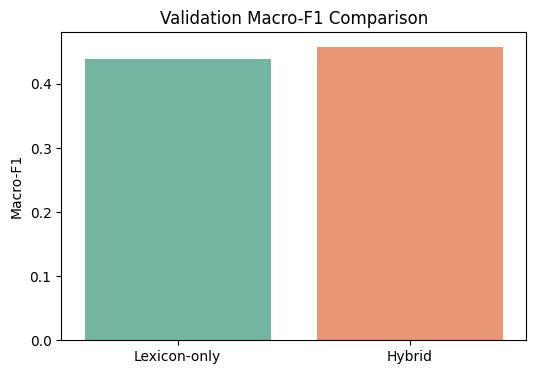

In [13]:
results = {
    "Lexicon-only": f1_score(y_val_enc, model_lex.predict(X_val_lex), average='macro'),
    "Hybrid": f1_score(y_val_enc, model_hybrid.predict(X_val_hybrid), average='macro')
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()),
            palette="Set2", hue=list(results.keys()), legend=False)

plt.title("Validation Macro-F1 Comparison")
plt.ylabel("Macro-F1")
plt.show()


## Section 8: Summary Table Comparison (Hardened)

Do not edit.  
This table shows side‑by‑side metrics for Lexicon‑only and Hybrid models, including accuracy, macro/micro precision/recall/F1, ROC‑AUC, and per‑class F1 scores.


In [14]:
# Safe scalar extractor (handles arrays, lists, Series, scalars)
def safe_scalar(x):
    if isinstance(x, (np.ndarray, list, tuple)):
        if len(x) == 0:
            return np.nan
        try:
            return float(np.mean(x))
        except Exception:
            return np.nan
    if isinstance(x, pd.Series):
        if x.size == 0:
            return np.nan
        try:
            return float(x.mean())
        except Exception:
            return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

# Collect metrics (keeps raw CV scores in results for plotting)
def collect_metrics(model, X_train, X_val, y_train_enc, y_val_enc, le, name):
    y_pred_val = model.predict(X_val)

    val_metrics = {
        "Accuracy": accuracy_score(y_val_enc, y_pred_val),
        "Macro Precision": precision_score(y_val_enc, y_pred_val, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_val_enc, y_pred_val, average='macro', zero_division=0),
        "Macro F1": f1_score(y_val_enc, y_pred_val, average='macro'),
        "Micro F1": f1_score(y_val_enc, y_pred_val, average='micro'),
        "ROC-AUC": roc_auc_score(y_val_enc, model.predict_proba(X_val), multi_class='ovr'),
    }

    # Per-class F1
    f1_per_class = f1_score(y_val_enc, y_pred_val, average=None)
    for cls in le.classes_:
        idx = le.transform([cls])[0]
        val_metrics[f"F1-{cls}"] = float(f1_per_class[idx])

    # Cross-validation (keep raw scores)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model.__class__(**model.get_params()),
                                X_train, y_train_enc, cv=cv, scoring='f1_macro', n_jobs=-1)
    val_metrics["CV Mean Macro-F1"] = float(np.mean(cv_scores))
    val_metrics["CV Std"] = float(np.std(cv_scores))
    val_metrics["CV Scores"] = cv_scores  # keep raw for plotting

    return val_metrics

# Collect results
results = {
    "Lexicon-only": collect_metrics(model_lex, X_train_lex, X_val_lex, y_train_enc, y_val_enc, le, "Lexicon-only"),
    "Hybrid":       collect_metrics(model_hybrid, X_train_hybrid, X_val_hybrid, y_train_enc, y_val_enc, le, "Hybrid")
}

# Build DataFrame (object dtype because of CV Scores arrays)
summary_table = pd.DataFrame(results).T

# Prepare display table: format CV as "mean ± std", round numeric columns
display_table = summary_table.copy()
if "CV Scores" in display_table.columns:
    display_table["CV Mean ± Std"] = display_table.apply(
        lambda row: f"{safe_scalar(row['CV Mean Macro-F1']):.3f} ± {safe_scalar(row['CV Std']):.3f}",
        axis=1
    )
    display_table = display_table.drop(columns=["CV Scores", "CV Mean Macro-F1", "CV Std"])

# Round numeric columns
for col in display_table.columns:
    # If all entries convertible to numeric, round them
    try:
        numeric_mask = display_table[col].apply(lambda x: np.isreal(safe_scalar(x)))
        if numeric_mask.all():
            display_table[col] = display_table[col].apply(lambda x: safe_scalar(x)).round(3)
    except Exception:
        pass

# Mark winners (numeric columns only)
marked_table = display_table.astype(object).copy()
for col in display_table.columns:
    col_vals = display_table[col].apply(safe_scalar)
    if col_vals.notna().all():
        best_idx = col_vals.idxmax()
        for idx in display_table.index:
            val = display_table.loc[idx, col]
            if isinstance(val, str):
                s = val
            else:
                s = f"{safe_scalar(val):.3f}"
            marked_table.loc[idx, col] = s
        marked_table.loc[best_idx, col] = str(marked_table.loc[best_idx, col]) + "  ⬆"
    else:
        marked_table[col] = marked_table[col].astype(str)

# Reorder to put CV Mean ± Std last (if present)
cols = [c for c in marked_table.columns if c != "CV Mean ± Std"] + (["CV Mean ± Std"] if "CV Mean ± Std" in marked_table.columns else [])
marked_table = marked_table[cols]

print("Validation vs CV Summary Table (better values marked):")
display(marked_table)

# Optional styled numeric table for nicer rendering
style_df = summary_table.drop(columns=["CV Scores"], errors='ignore').copy()
for c in style_df.columns:
    style_df[c] = style_df[c].apply(safe_scalar)
def highlight_winner(s):
    vals = s.apply(safe_scalar)
    if vals.notna().all():
        winner = vals.idxmax()
        return ['background-color: #dda0dd' if idx == winner else '' for idx in s.index]
    return ['' for _ in s.index]
styled = style_df.style.format("{:.3f}").apply(highlight_winner, axis=0)
display(styled)


Validation vs CV Summary Table (better values marked):


,Accuracy,Macro Precision,Macro Recall,Macro F1,Micro F1,ROC-AUC,F1-negative,F1-neutral,F1-positive,CV Mean ± Std
Lexicon-only,0.787 ⬆,0.462,0.427,0.439,0.787 ⬆,0.719 ⬆,0.346,0.085,0.886 ⬆,nan
Hybrid,0.734,0.465 ⬆,0.461 ⬆,0.458 ⬆,0.734,0.718,0.352 ⬆,0.169 ⬆,0.852,nan


,Accuracy,Macro Precision,Macro Recall,Macro F1,Micro F1,ROC-AUC,F1-negative,F1-neutral,F1-positive,CV Mean Macro-F1,CV Std
Lexicon-only,0.787,0.462,0.427,0.439,0.787,0.719,0.346,0.085,0.886,0.398,0.004
Hybrid,0.734,0.465,0.461,0.458,0.734,0.718,0.352,0.169,0.852,0.526,0.003


<Figure size 600x400 with 0 Axes>

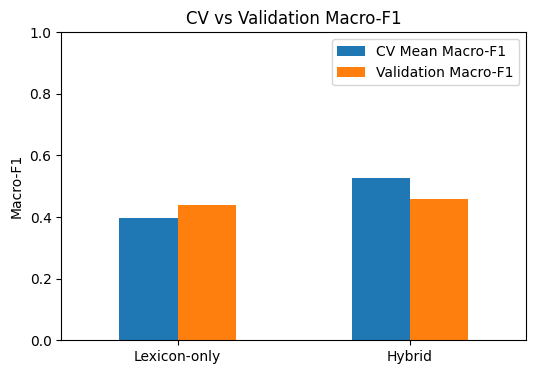

C:\Users\Admin\AppData\Local\Temp\ipykernel_8720\904453663.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  per_class_data = summary_table[per_class_cols].applymap(safe_scalar).T


<Figure size 800x500 with 0 Axes>

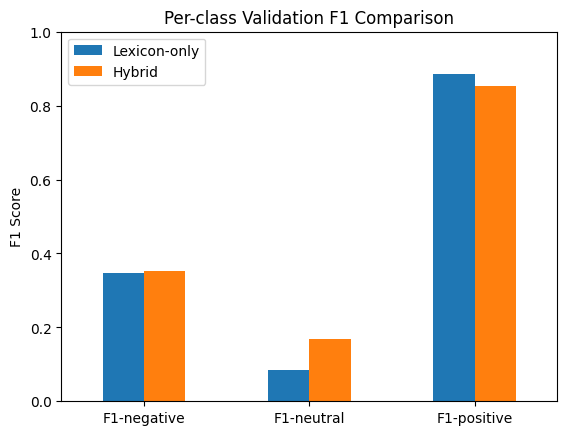

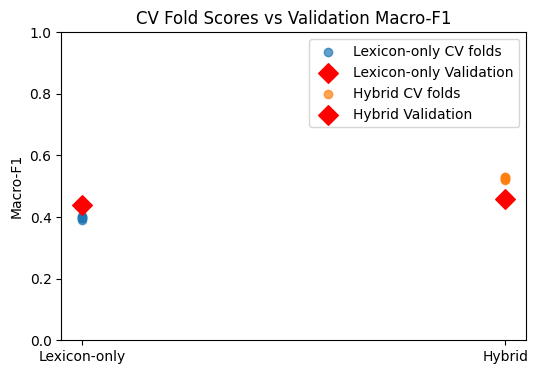

In [15]:
# Barplot: CV mean vs Validation Macro-F1
cv_val_data = pd.DataFrame({
    "Lexicon-only": [
        safe_scalar(results["Lexicon-only"]["CV Mean Macro-F1"]),
        safe_scalar(results["Lexicon-only"]["Macro F1"])
    ],
    "Hybrid": [
        safe_scalar(results["Hybrid"]["CV Mean Macro-F1"]),
        safe_scalar(results["Hybrid"]["Macro F1"])
    ]
}, index=["CV Mean Macro-F1", "Validation Macro-F1"])

plt.figure(figsize=(6,4))
cv_val_data.T.plot(kind="bar", rot=0, figsize=(6,4))
plt.title("CV vs Validation Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0,1)
plt.show()

# Grouped barplot: per-class F1 (from summary_table columns F1-*)
per_class_cols = [c for c in summary_table.columns if c.startswith("F1-")]
if per_class_cols:
    per_class_data = summary_table[per_class_cols].applymap(safe_scalar).T
    per_class_data.columns = summary_table.index
    plt.figure(figsize=(8,5))
    per_class_data.plot(kind="bar")
    plt.title("Per-class Validation F1 Comparison")
    plt.ylabel("F1 Score")
    plt.ylim(0,1)
    plt.xticks(rotation=0)
    plt.show()

# Scatter: CV fold scores vs Validation Macro-F1
plt.figure(figsize=(6,4))
for model_name in results.keys():
    cv_scores = results[model_name]["CV Scores"]
    val_score = safe_scalar(summary_table.loc[model_name, "Macro F1"])
    plt.scatter([model_name]*len(cv_scores), cv_scores, alpha=0.7, label=f"{model_name} CV folds")
    plt.scatter(model_name, val_score, marker="D", color="red", s=100, label=f"{model_name} Validation")
plt.title("CV Fold Scores vs Validation Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0,1)
plt.legend()
plt.show()


In [16]:


# ---------------------------
# Metrics Computation
# ---------------------------
def compute_metrics(y_true, y_pred, label_order=[0,1,2]):
    metrics = {}
    metrics['Accuracy'] = accuracy_score(y_true, y_pred)
    metrics['Macro F1'] = f1_score(y_true, y_pred, average='macro')
    metrics['F1-negative'] = f1_score(y_true, y_pred, labels=[0], average='macro')
    metrics['F1-neutral'] = f1_score(y_true, y_pred, labels=[1], average='macro')
    metrics['F1-positive'] = f1_score(y_true, y_pred, labels=[2], average='macro')
    
    try:
        y_true_ohe = pd.get_dummies(y_true)
        y_pred_ohe = pd.get_dummies(y_pred)
        metrics['ROC-AUC'] = roc_auc_score(y_true_ohe, y_pred_ohe, average='macro')
    except Exception:
        metrics['ROC-AUC'] = None
    return metrics

# ---------------------------
# Diagnostics
# ---------------------------
class ModelDiagnostics:
    def __init__(self, model, X_train, X_val, y_train, y_val, name="Model"):
        self.model = model
        self.X_train = X_train
        self.X_val = X_val
        self.y_train = y_train
        self.y_val = y_val
        self.name = name

    def summary(self):
        print(f"\n--- Diagnostics: {self.name} ---")
        print("X_train shape:", getattr(self.X_train, "shape", None))
        print("X_val shape:", getattr(self.X_val, "shape", None))
        print("y_train counts:", pd.Series(self.y_train).value_counts().sort_index().to_dict())
        print("y_val counts:", pd.Series(self.y_val).value_counts().sort_index().to_dict())
        print("Model class:", self.model.__class__.__name__)
        if hasattr(self.model, "_compute_inverse_freq_priors"):
            priors = self.model._compute_inverse_freq_priors(np.array(self.y_train))
            print("Inverse-freq priors:", priors)
            print("Sum of priors:", np.sum(priors))

# ---------------------------
# Plotting Helpers
# ---------------------------
def plot_confusion(y_true, y_pred, label_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def plot_f1_bars(metrics_dict, label_names):
    plt.figure(figsize=(7,4))
    for variant_feat, metrics in metrics_dict.items():
        f1_vals = [metrics['F1-negative'], metrics['F1-neutral'], metrics['F1-positive']]
        plt.bar(label_names, f1_vals, alpha=0.5, label=variant_feat)
    plt.ylabel("F1 Score")
    plt.legend()
    plt.show()

# ---------------------------
# Training + Evaluation
# ---------------------------
def train_and_evaluate(model, X_train, X_val, y_train, y_val, label_encoder=None, name="Model", chunk_size=100000):
    model.fit(X_train, y_train)
    
    # Predict in chunks to avoid converting the entire sparse matrix to dense at once
    y_pred = []
    n_samples = X_val.shape[0]
    # Ensure X_val is sliceable
    if sp.issparse(X_val):
        X_val_sliceable = X_val.tocsr()
    else:
        X_val_sliceable = X_val

    y_pred = []
    n_samples = X_val_sliceable.shape[0]
    for start in range(0, n_samples, chunk_size):
        end = min(start + chunk_size, n_samples)
        y_pred_chunk = model.predict(X_val_sliceable[start:end])
        y_pred.append(y_pred_chunk)
    y_pred = np.concatenate(y_pred)

    
    metrics = compute_metrics(y_val, y_pred)
    print(f"\n=== {name} Results ===")
    print(f"Accuracy: {metrics['Accuracy']:.3f}, Macro F1: {metrics['Macro F1']:.3f}, ROC-AUC: {metrics['ROC-AUC']}")
    
    return y_pred, model, metrics


# ---------------------------
# Experiment Runner
# ---------------------------
class ExperimentRunner:
    def __init__(self, model_class, variants, X_train_dict, X_val_dict, y_train, y_val, le=None):
        self.model_class = model_class
        self.variants = variants
        self.X_train_dict = X_train_dict
        self.X_val_dict = X_val_dict
        self.y_train = y_train
        self.y_val = y_val
        self.le = le
        self.results = {}  # store models, preds, metrics

    def run_all(self):
        for variant_name, kwargs in self.variants.items():
            self.results[variant_name] = {}
            for feat_name, X_tr in self.X_train_dict.items():
                X_val = self.X_val_dict[feat_name]
                print(f"\nRunning: {variant_name} - {feat_name}")
                model = self.model_class(**kwargs)
                y_pred, trained_model, metrics = train_and_evaluate(
                    model, X_tr, X_val, self.y_train, self.y_val, self.le, f"{variant_name} - {feat_name}"
                )
                self.results[variant_name][feat_name] = {
                    "model": trained_model,
                    "y_pred": y_pred,
                    "metrics": metrics
                }
        return self.results

# ---------------------------
# Build Summary Table
# ---------------------------
def build_summary_table(results_dict, add_arrows=True):
    """
    Build a summary table from results_dict.
    If add_arrows=True, append '⬆' to the maximum value in each metric column.
    """
    # 1️⃣ Build the raw table
    rows = []
    for variant, feat_dict in results_dict.items():
        for feat_set, res in feat_dict.items():
            metrics = res['metrics']
            row = {
                "Variant": variant,
                "Feature set": feat_set,
                "Accuracy": metrics['Accuracy'],
                "Macro F1": metrics['Macro F1'],
                "ROC-AUC": metrics['ROC-AUC'],
                "F1-negative": metrics['F1-negative'],
                "F1-neutral": metrics['F1-neutral'],
                "F1-positive": metrics['F1-positive'],
            }
            rows.append(row)
    
    df = pd.DataFrame(rows)

    # 2️⃣ Add arrows if requested
    if add_arrows:
        arrow_cols = ["Accuracy", "Macro F1", "ROC-AUC", "F1-negative", "F1-neutral", "F1-positive"]
        for col in arrow_cols:
            max_val = df[col].max()
            df[col] = df[col].apply(lambda x: f"{x:.3f} ⬆" if x == max_val else f"{x:.3f}")
    
    return df


# ============================================
# Example Usage
# ============================================

# Define feature sets
X_train_dict = {"Lexicon": X_train_lex, "Hybrid": X_train_hybrid}
X_val_dict   = {"Lexicon": X_val_lex, "Hybrid": X_val_hybrid}

# Define variants
base_kwargs = {"svd_n_components":100, "lda_solver":"lsqr", "lda_shrinkage":"auto", "upsample_neutral":False, "upsample_n":None}
variants = {
    "baseline": dict(base_kwargs, upsample_neutral=False),
    "priors_only": dict(base_kwargs, upsample_neutral=False),
    "upsample_only": dict(base_kwargs, upsample_neutral=True, upsample_n=200000),
    "priors_plus_upsample": dict(base_kwargs, upsample_neutral=True, upsample_n=200000)
}

# Run experiments
runner = ExperimentRunner(FisherEstimator, variants, X_train_dict, X_val_dict, y_train_enc, y_val_enc)
results = runner.run_all()

# Diagnostics example
diag = ModelDiagnostics(results['baseline']['Lexicon']['model'], X_train_lex, X_val_lex, y_train_enc, y_val_enc, "Baseline Lexicon")
diag.summary()

# Build summary table
summary_df = build_summary_table(results)
summary_df



Running: baseline - Lexicon

=== baseline - Lexicon Results ===
Accuracy: 0.787, Macro F1: 0.439, ROC-AUC: 0.5822181565520431

Running: baseline - Hybrid

=== baseline - Hybrid Results ===
Accuracy: 0.734, Macro F1: 0.458, ROC-AUC: 0.6069813728480687

Running: priors_only - Lexicon

=== priors_only - Lexicon Results ===
Accuracy: 0.787, Macro F1: 0.439, ROC-AUC: 0.5822181565520431

Running: priors_only - Hybrid

=== priors_only - Hybrid Results ===
Accuracy: 0.734, Macro F1: 0.458, ROC-AUC: 0.6069813728480687

Running: upsample_only - Lexicon

=== upsample_only - Lexicon Results ===
Accuracy: 0.599, Macro F1: 0.350, ROC-AUC: 0.5961923303803108

Running: upsample_only - Hybrid

=== upsample_only - Hybrid Results ===
Accuracy: 0.793, Macro F1: 0.435, ROC-AUC: 0.5887746113151707

Running: priors_plus_upsample - Lexicon

=== priors_plus_upsample - Lexicon Results ===
Accuracy: 0.599, Macro F1: 0.350, ROC-AUC: 0.5961923303803108

Running: priors_plus_upsample - Hybrid

=== priors_plus_upsa

,Variant,Feature set,Accuracy,Macro F1,ROC-AUC,F1-negative,F1-neutral,F1-positive
0,baseline,Lexicon,0.787,0.439,0.582,0.346,0.085,0.886 ⬆
1,baseline,Hybrid,0.734,0.458 ⬆,0.607 ⬆,0.352,0.169,0.852
2,priors_only,Lexicon,0.787,0.439,0.582,0.346,0.085,0.886 ⬆
3,priors_only,Hybrid,0.734,0.458 ⬆,0.607 ⬆,0.352,0.169,0.852
4,upsample_only,Lexicon,0.599,0.350,0.596,0.094,0.183 ⬆,0.772
5,upsample_only,Hybrid,0.793 ⬆,0.435,0.589,0.356 ⬆,0.065,0.885
6,priors_plus_upsample,Lexicon,0.599,0.350,0.596,0.094,0.183 ⬆,0.772
7,priors_plus_upsample,Hybrid,0.793 ⬆,0.435,0.589,0.356 ⬆,0.065,0.885


# Graphs

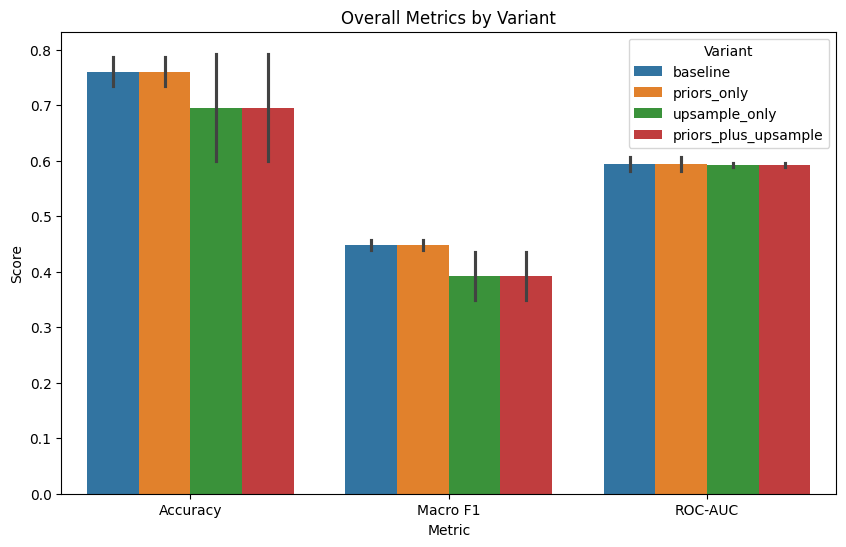

In [17]:
# Bar chart for Accuracy, Macro F1, ROC-AUC
def plot_summary_metrics(summary_df):
    metrics_to_plot = ["Accuracy", "Macro F1", "ROC-AUC"]
    df_plot = summary_df.copy()
    
    # Remove arrows if present
    for col in metrics_to_plot:
        df_plot[col] = df_plot[col].astype(str).str.replace(" ⬆","").astype(float)
    
    melted = df_plot.melt(id_vars=["Variant","Feature set"], value_vars=metrics_to_plot,
                          var_name="Metric", value_name="Score")
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=melted, x="Metric", y="Score", hue="Variant")
    plt.title("Overall Metrics by Variant")
    plt.ylabel("Score")
    plt.legend(title="Variant")
    plt.show()

# Example usage
plot_summary_metrics(summary_df)


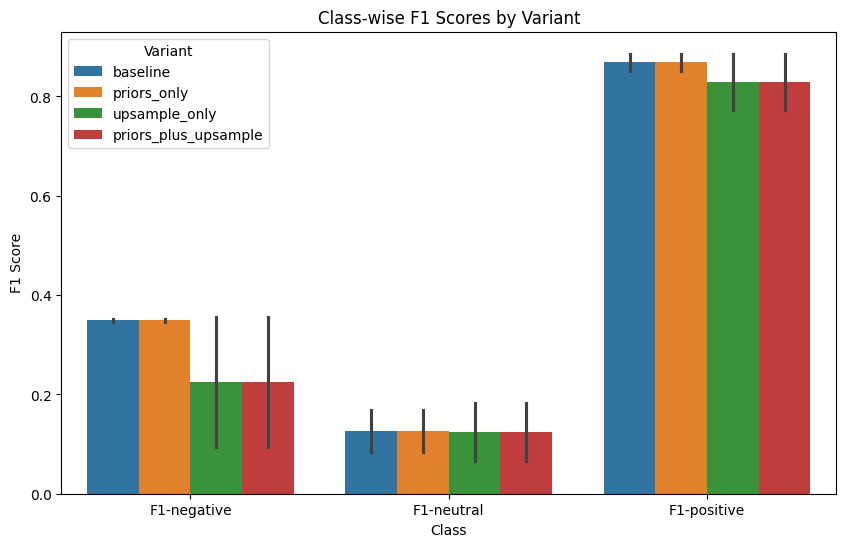

In [18]:
def plot_classwise_f1(summary_df):
    f1_cols = ["F1-negative","F1-neutral","F1-positive"]
    df_plot = summary_df.copy()
    for col in f1_cols:
        df_plot[col] = df_plot[col].astype(str).str.replace(" ⬆","").astype(float)
    
    melted = df_plot.melt(id_vars=["Variant","Feature set"], value_vars=f1_cols,
                          var_name="Class", value_name="F1 Score")
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=melted, x="Class", y="F1 Score", hue="Variant")
    plt.title("Class-wise F1 Scores by Variant")
    plt.ylabel("F1 Score")
    plt.legend(title="Variant")
    plt.show()

# Example usage
plot_classwise_f1(summary_df)


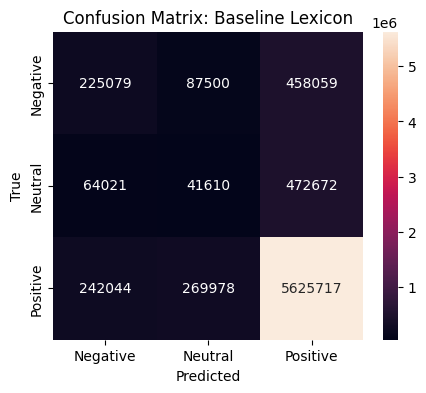

In [19]:
# Example: plot confusion matrix for baseline Lexicon
y_true = y_val_enc
y_pred = results['baseline']['Lexicon']['y_pred']
label_names = ["Negative","Neutral","Positive"]

plot_confusion(y_true, y_pred, label_names, "Confusion Matrix: Baseline Lexicon")


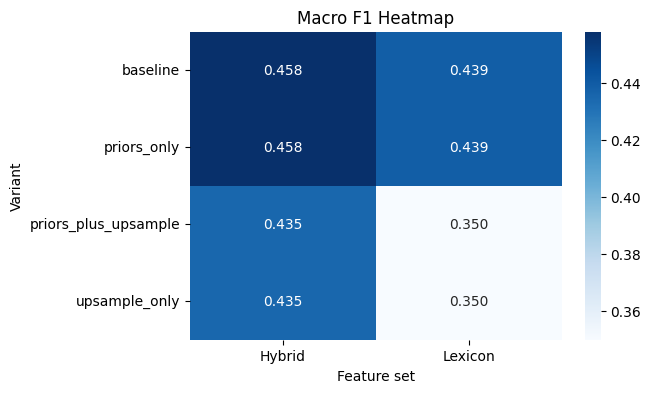

In [20]:
def plot_metric_heatmap(summary_df, metric="Macro F1"):
    df_plot = summary_df.copy()
    df_plot[metric] = df_plot[metric].astype(str).str.replace(" ⬆","").astype(float)
    
    pivot = df_plot.pivot(index="Variant", columns="Feature set", values=metric)
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues")
    plt.title(f"{metric} Heatmap")
    plt.show()

# Example usage
plot_metric_heatmap(summary_df, metric="Macro F1")
